# Empathy Detection Classifier Model 
**Task:** Build and evaluate an end-to-end Machine Learning model to detect empathy in online forum posts.

### Flow:
1. **Environment Setup & Data Ingestion:** Load essential libraries and the raw dataset.
2. **Phase 1 — Data Cleaning & Preprocessing:** Sanitize text, remove malformed records, and handle post lengths.
3. **Phase 2 — Feature Extraction (TF-IDF):** Split data into Train/Test sets (70/30) and vectorize text.
4. **Phase 3 — Model Training & Optimization:** Train Logistic Regression with balanced weights and tune hyperparameters.
5. **Phase 4 — Model Evaluation & Diagnostics:** Measure performance using F1-score, Confusion Matrix, and PR-AUC.
6. **Phase 5 — Pipeline Packaging & Inference:** Save the full pipeline artifact and test live predictions.


## Setup: Imports & Local Data Loading
**Overview:**
* Import all required core data science and machine learning libraries (`pandas`, `numpy`, `scikit-learn`, `matplotlib`).
* Load the local raw dataset (`AcnEmpathize_dataset.csv`) into the workspace.


In [1]:
# Core imports
import pandas as pd
import numpy as np
import re
import html
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve
)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)

In [ ]:
import os

# look for the dataset in the local dataset folder
candidate_paths = [
    "dataset/AcnEmpathize_dataset.csv",
]

csv_filename = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_filename:
    print(f"Found and loaded local dataset: {csv_filename}")
else:
    raise FileNotFoundError("Could not find AcnEmpathize_dataset.csv. Please check the path.")

Found and loaded local dataset: dataset/AcnEmpathize_dataset.csv


## Phase 1.1 — Data Ingestion & Initial Cleaning
**Overview:**
* **Parse CSV Safely:** Handle unescaped commas by dropping malformed stray trailing columns.
* **Keep Essential Columns:** Extract only `text` (post content) and `combined_empathy` (target label).
* **Label Validation:** Ensure all labels are strictly numeric binary (`0` = Not Empathetic, `1` = Empathetic) and drop corrupted rows.


In [3]:
raw_df = pd.read_csv(csv_filename, engine='python', on_bad_lines='warn')
print(f"Raw dataset shape: {raw_df.shape}")

# Validate required columns
assert 'text' in raw_df.columns, "Expected 'text' column in dataset"
assert 'combined_empathy' in raw_df.columns, "Expected 'combined_empathy' column in dataset"

# Extract only the target columns (dropping stray malformed columns)
df = raw_df[['text', 'combined_empathy']].copy()

# Clean and validate labels: coerce invalid values and retain strictly binary 0/1
df['combined_empathy'] = pd.to_numeric(df['combined_empathy'], errors='coerce')
df = df.dropna(subset=['combined_empathy'])

df = df[df['combined_empathy'].isin([0, 1])]
df['combined_empathy'] = df['combined_empathy'].astype(int)

print(f"Sanitized dataset shape: {df.shape}")
print(f"\nClass distribution:\n\n{df['combined_empathy'].value_counts()}")

Raw dataset shape: (12214, 1816)
Sanitized dataset shape: (12211, 2)

Class distribution:

combined_empathy
0    9235
1    2976
Name: count, dtype: int64


## Phase 1.2 — Text Cleaning & Length Normalization
**Overview:**
* **Clean Text:** Strip HTML entities, remove web URLs, and normalize excessive whitespace.
* **Remove Noise:** Discard extremely short posts (less than 3 words).
* **Handle Outliers:** Truncate exceptionally long posts at the 99th percentile (778 words) so extreme lengths do not distort vocabulary.


In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # URLs
    text = re.sub(r'\s+', ' ', text).strip()                # excessive whitespace/newlines
    return text

df['text_clean'] = df['text'].apply(clean_text)
df['word_count'] = df['text_clean'].str.split().str.len().fillna(0).astype(int)

# Check short rows before dropping anything
short_mask = df['word_count'] < 3

print(f"Rows with < 3 words post-cleaning: {short_mask.sum()} ({short_mask.mean()*100:.2f}%)")

Rows with < 3 words post-cleaning: 154 (1.26%)


In [5]:
# drop rows under 3 words (confirm after inspecting output above)
rows_before_short_drop = len(df)

df = df[~short_mask].copy()
print(f"Dropped {rows_before_short_drop - len(df)} short rows. Remaining: {len(df)}")

# Length handling — truncate at 99th percentile
p99 = int(df['word_count'].quantile(0.99))
print(f"99th percentile word count: {p99}")

def truncate_words(text, max_words):
    words = text.split()
    return ' '.join(words[:max_words])

df['text_final'] = df['text_clean'].apply(lambda t: truncate_words(t, p99))

# Log length distribution split by class — potential signal or leakage risk
print(df.groupby('combined_empathy')['word_count'].describe()[['mean', '50%', 'max']])


Dropped 154 short rows. Remaining: 12057
99th percentile word count: 778
                        mean    50%     max
combined_empathy                           
0                 118.033917   67.0  4785.0
1                 173.007392  126.0  5601.0


## Phase 2 — Data Splitting & Feature Extraction (TF-IDF)
**Overview:**
* **70/30 Stratified Split:** Divide data into Training (8,439 samples) and Testing (3,618 samples) sets while preserving class balance.
* **TF-IDF Vectorization:** Convert raw text into numerical features using unigrams and bigrams (e.g., *"I understand"*).
* **Prevent Data Leakage:** Fit the vectorizer strictly on training data, then transform the test set separately.


In [6]:
# --- Phase 2: Stratified split + TF-IDF (fit on train only) ---
X = df['text_final']
y = df['combined_empathy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}\n")
print(f"Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)   # fit ONLY on train
X_test_tfidf = vectorizer.transform(X_test)          # transform test separately — no leakage

print(f"TF-IDF vocab size: {len(vectorizer.vocabulary_)}")
print(f"Train matrix shape: {X_train_tfidf.shape}")


Train: 8439  Test: 3618

Train class balance:
 combined_empathy
0    0.75317
1    0.24683
Name: proportion, dtype: float64
Test class balance:
 combined_empathy
0    0.753179
1    0.246821
Name: proportion, dtype: float64
TF-IDF vocab size: 8000
Train matrix shape: (8439, 8000)


## Phase 3 — Model Training
**Overview:**
* **Algorithm:** Train a Logistic Regression classifier with L2 regularization.
* **Handle Imbalance:** Use `class_weight='balanced'` so minority empathetic samples are appropriately weighted.
* **5-Fold Cross-Validation:** Perform Grid Search over regularization parameter `C` optimizing for minority class F1-score.


In [7]:
# Phase 3: Logistic Regression + GridSearchCV tuned on F1 
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    base_model, param_grid, scoring='f1', cv=cv, n_jobs=-1
)
grid_search.fit(X_train_tfidf, y_train)

model = grid_search.best_estimator_

## Phase 4 — Model Evaluation
**Overview:**
* **Evaluate on Test Set:** Run the best model on unseen holdout test data.
* **Key Metrics:** Calculate Precision, Recall, F1-score, and Precision-Recall AUC (PR-AUC).
* **Visual Diagnostics:** Plot the Confusion Matrix and Precision-Recall Curve to inspect prediction quality.


In [8]:
# Metrics on held-out test set (touched once)
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

print("Per-class classification report:")
print(classification_report(y_test, y_pred, target_names=['class 0', 'class 1 (empathetic)'], digits=3))

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}  (more informative than ROC-AUC here given the 76/24 imbalance)")

Per-class classification report:
                      precision    recall  f1-score   support

             class 0      0.903     0.833     0.866      2725
class 1 (empathetic)      0.587     0.726     0.649       893

            accuracy                          0.806      3618
           macro avg      0.745     0.779     0.758      3618
        weighted avg      0.825     0.806     0.813      3618

ROC-AUC: 0.8535
PR-AUC:  0.6890  (more informative than ROC-AUC here given the 76/24 imbalance)


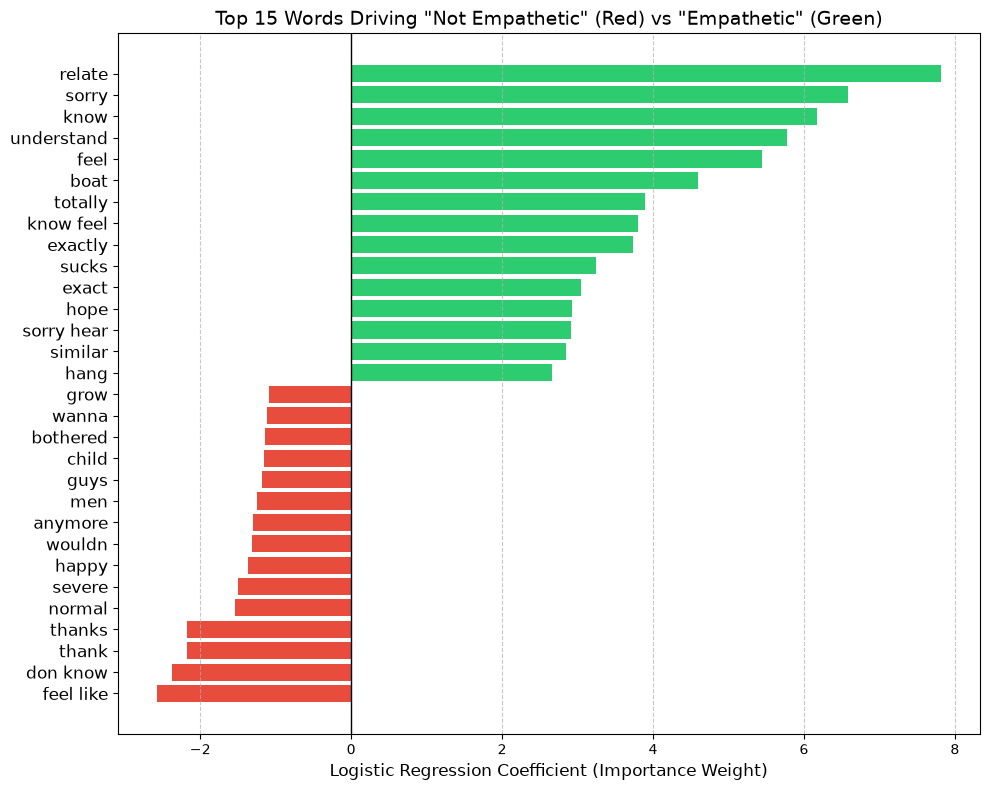

In [9]:
# Top Empathy Words Bar Chart
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Extract top 15 words for both classes
top_positive_idx = np.argsort(coefficients)[-15:]
top_negative_idx = np.argsort(coefficients)[:15]

top_indices = np.concatenate([top_negative_idx, top_positive_idx])
top_features = feature_names[top_indices]
top_coefficients = coefficients[top_indices]

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_coefficients]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_coefficients, color=colors)
plt.yticks(range(len(top_features)), top_features, fontsize=12)
plt.xlabel('Logistic Regression Coefficient (Importance Weight)', fontsize=12)
plt.title('Top 15 Words Driving "Not Empathetic" (Red) vs "Empathetic" (Green)', fontsize=14)
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

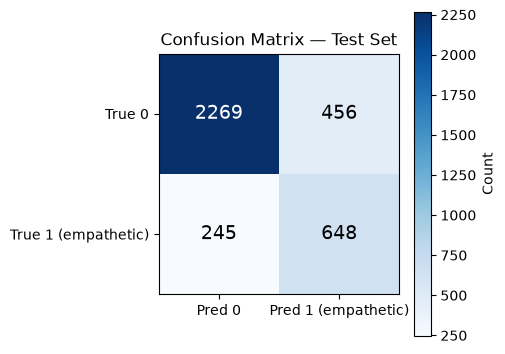

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1 (empathetic)'])
ax.set_yticklabels(['True 0', 'True 1 (empathetic)'])
ax.set_title('Confusion Matrix — Test Set')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

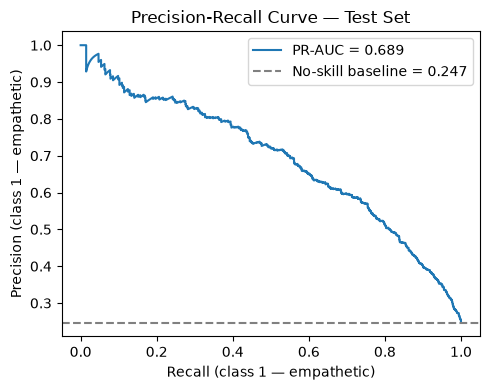

In [11]:
# Precision-Recall curve (PR-AUC > ROC-AUC given imbalance)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(5, 4))

plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
baseline = y_test.mean()

plt.axhline(baseline, color='gray', linestyle='--', label=f'No-skill baseline = {baseline:.3f}')

plt.xlabel('Recall (class 1 — empathetic)')
plt.ylabel('Precision (class 1 — empathetic)')

plt.title('Precision-Recall Curve — Test Set')

plt.legend()

plt.tight_layout()
plt.show()

## Phase 5 — Design Pipeline (Vectorizer + Model)
**Overview:**
* **Bundle Components:** Combine the fitted TF-IDF vectorizer and trained Logistic Regression model into a single `sklearn.pipeline.Pipeline`.
* **Save Model Artifact:** Serialize the entire pipeline to `empathy_detection_pipeline.joblib` for reproducible deployment.


In [ ]:
# Phase 5: Wrap into a single Pipeline, serialize
full_pipeline = Pipeline([1
    ('tfidf', vectorizer),
    ('clf', model)
])

# Pipeline already holds the fitted vectorizer + fitted model — no need to refit
joblib.dump(full_pipeline, 'empathy_detection_pipeline.joblib')

['empathy_detection_pipeline.joblib']

## Phase 5 — Inference Pipeline
**Overview:**
* **Inference Pipeline:** Define `predict_empathy(text)` to clean, vectorize, and score raw user text.
* **Output Format:** Returns the predicted binary label (`0` or `1`) along with the model's confidence probability.
* **Interactive Testing:** Test custom sentences in real-time.


In [ ]:
# Inference function
def predict_empathy(text, pipeline=full_pipeline, max_words=p99):
    cleaned = clean_text(text)
    cleaned = truncate_words(cleaned, max_words)
    proba = pipeline.predict_proba([cleaned])[0]
    label = int(np.argmax(proba))
    confidence = float(proba[label])
    return {'label': label, 'confidence': round(confidence, 4)}

# Quick sanity check
print(predict_empathy("I understand how frustrating this acne has been for you, that sounds really hard."))
print(predict_empathy("Use benzoyl peroxide twice daily and see a dermatologist."))

{'label': 1, 'confidence': 0.8551}
{'label': 0, 'confidence': 0.9187}


In [12]:
# User Input - Empathy Detection
user_text = input("Write something about your acne experience: ")
result = predict_empathy(user_text)

status = "empathetic" if result['label'] == 1 else "not empathetic"

confidence_percentage = f"{result['confidence'] * 100}" 

print(f"Your sentence is {status}. Confidence is {confidence_percentage}%")

NameError: name 'predict_empathy' is not defined